In [4]:
#Importing necessary librarires 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
import string
string.punctuation
s = string.punctuation

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
import pickle


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\omkar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
df = pd.read_json("Cell_Phones_and_Accessories_5.json", lines=True)
# keep only the desired columns
df = df[['reviewText', 'overall', 'summary']]

In [6]:
df.sample(10)

,reviewText,overall,summary
174458,"Great case. Very reliable and strong. Also, it...",5,"Reliable, good looking, and sturdy!"
137446,I don't completely trust this case but if I'm ...,5,I use it at the pool
194018,I love how clear this protector is a great pro...,5,Five Stars
94060,This went on easily. It is mirror finish. You ...,3,Its what is says it is
33219,Es lo mejor y mas seguro que he encontrado has...,5,Muy buen producto.
176458,I wanted something a little more rugged for bu...,5,Just what I was looking for
1140,This is the second HS850 Motorola I have purch...,4,Great Bargain Bluetooth
164793,"This is a perfect case for my Nokia lumia 928,...",5,Love this case
71736,love it..sharp looking and i like the way the ...,5,phone case
107562,"Nice and easy application, good range of cover...",5,"Good product, what you expect!"


In [7]:
#Workflow Of project
#1. Data Cleaning
#2. Data Preprocessing

In [8]:
#DATA CLEANING

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194439 entries, 0 to 194438
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   reviewText  194439 non-null  object
 1   overall     194439 non-null  int64 
 2   summary     194439 non-null  object
dtypes: int64(1), object(2)
memory usage: 4.5+ MB


In [10]:
df.columns

Index(['reviewText', 'overall', 'summary'], dtype='object')

In [11]:
print(df.head())

                                          reviewText  overall  \
0  They look good and stick good! I just don't li...        4   
1  These stickers work like the review says they ...        5   
2  These are awesome and make my phone look so st...        5   
3  Item arrived in great time and was in perfect ...        4   
4  awesome! stays on, and looks great. can be use...        5   

                                     summary  
0                                 Looks Good  
1                      Really great product.  
2                             LOVE LOVE LOVE  
3                                      Cute!  
4  leopard home button sticker for iphone 4s  


In [12]:
#Not keeping 3-star reviews as they are neutral
#and do not contribute to the sentiment analysis
df = df[df['overall'] != 3]

In [13]:
#Converting ratings to binary  labels: 
#1 for positive reviews (4 and 5 stars)
#0 for negative reviews (1 and 2 stars)

def sentiment_label(ratings):
    if ratings >= 4:
        return 1
    else:
        return 0
    
df["sentiment(label)"] = df["overall"].apply(sentiment_label)

In [14]:
df.head()

,reviewText,overall,summary,sentiment(label)
0,They look good and stick good! I just don't li...,4,Looks Good,1
1,These stickers work like the review says they ...,5,Really great product.,1
2,These are awesome and make my phone look so st...,5,LOVE LOVE LOVE,1
3,Item arrived in great time and was in perfect ...,4,Cute!,1
4,"awesome! stays on, and looks great. can be use...",5,leopard home button sticker for iphone 4s,1


In [15]:
#Combining reviewText and summary into single columns for better analysis
df["Review"] = df["reviewText"] + " " + df["summary"]
df = df[["Review", "sentiment(label)"]]

In [16]:
df.head()

,Review,sentiment(label)
0,They look good and stick good! I just don't li...,1
1,These stickers work like the review says they ...,1
2,These are awesome and make my phone look so st...,1
3,Item arrived in great time and was in perfect ...,1
4,"awesome! stays on, and looks great. can be use...",1


In [17]:
df.shape

(173000, 2)

In [18]:
#data cleaning is done. We have 173000 rows and 2 columns in our dataset.

In [19]:
#EXPLORATORY DATA ANALYSIS(EDA)

In [20]:
df.head()

,Review,sentiment(label)
0,They look good and stick good! I just don't li...,1
1,These stickers work like the review says they ...,1
2,These are awesome and make my phone look so st...,1
3,Item arrived in great time and was in perfect ...,1
4,"awesome! stays on, and looks great. can be use...",1


In [21]:
df['sentiment(label)'].value_counts()
#Checkinng distribution of positive and negative reviews

sentiment(label)
1    148657
0     24343
Name: count, dtype: int64

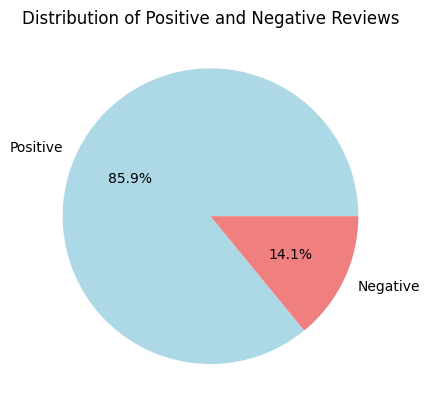

In [22]:
import matplotlib.pyplot as plt
plt.pie(df['sentiment(label)'].value_counts(), labels=['Positive', 'Negative'], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Distribution of Positive and Negative Reviews')
plt.show()

In [23]:
#Dataset is imbalanced as we have more positive reviews than negative reviews.


In [24]:
#Now, we will  create 3 new columns in our dataset which will give us  more insights about the messages.
#These colummns are
#1. word_count: This column will give us the number of words in each review.
#2. char_count: This column will give us the number of characters in each review.
#3. sentence_count: This column will give us the number of sentences in each review.

In [25]:
df['char_count'] = df['Review'].apply(len)
#Number of characters in each review

In [26]:
#Using split() function instead of nltk.tokenize() to count the number of words in each review as it is faster and more efficient.

df['word_count'] = df['Review'].apply(lambda x: len((str(x).split())))
#Number of words in each review

In [27]:
df['sentence_count'] = df['Review'].apply(lambda x:  len(str(x).split('.')))
#Number of sentences in each review

In [28]:
df.head()

,Review,sentiment(label),char_count,word_count,sentence_count
0,They look good and stick good! I just don't li...,1,200,39,2
1,These stickers work like the review says they ...,1,182,35,5
2,These are awesome and make my phone look so st...,1,181,37,1
3,Item arrived in great time and was in perfect ...,1,281,52,5
4,"awesome! stays on, and looks great. can be use...",1,177,30,4


In [29]:
df.shape

(173000, 5)

In [30]:
#Analysing overall insights
df[['char_count', 'word_count', 'sentence_count']].describe()

,char_count,word_count,sentence_count
count,173000.000000,173000.000000,173000.000000
mean,513.248318,95.191260,7.338590
std,757.364243,136.209942,8.886188
min,4.000000,1.000000,1.000000
25%,161.000000,31.000000,3.000000
50%,268.000000,51.000000,5.000000
75%,556.000000,104.000000,8.000000
max,32143.000000,5275.000000,332.000000


In [31]:
#Positive reviews 
df[df['sentiment(label)'] == 1][['char_count', 'word_count', 'sentence_count']].describe()

,char_count,word_count,sentence_count
count,148657.000000,148657.000000,148657.000000
mean,517.624256,95.939962,7.313823
std,775.824707,139.530909,9.016048
min,9.000000,1.000000,1.000000
25%,160.000000,30.000000,3.000000
50%,266.000000,51.000000,5.000000
75%,558.000000,105.000000,8.000000
max,32143.000000,5275.000000,332.000000


In [32]:
#Negative reviews
df[df['sentiment(label)'] == 0][['char_count', 'word_count', 'sentence_count']].describe()

,char_count,word_count,sentence_count
count,24343.000000,24343.000000,24343.000000
mean,486.525490,90.619110,7.489833
std,632.412071,113.742091,8.046337
min,4.000000,1.000000,1.000000
25%,170.000000,33.000000,3.000000
50%,283.000000,54.000000,5.000000
75%,543.000000,102.000000,9.000000
max,14784.000000,2552.000000,223.000000


In [33]:
df.shape

(173000, 5)

<Axes: xlabel='char_count', ylabel='Count'>

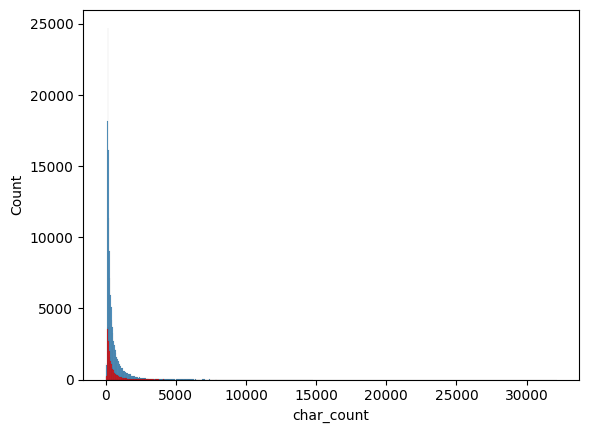

In [34]:
sns.histplot(df[df['sentiment(label)']==1]['char_count']) #Positive reviews

sns.histplot(df[df['sentiment(label)']==0]['char_count'], color='red') #Negative reviews

<Axes: xlabel='word_count', ylabel='Count'>

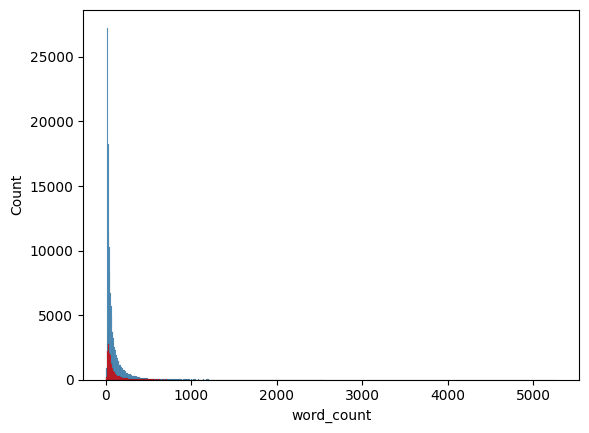

In [35]:
sns.histplot(df[df['sentiment(label)']==1]['word_count']) #Positive reviews

sns.histplot(df[df['sentiment(label)']==0]['word_count'], color='red') #Negative reviews

<Axes: >

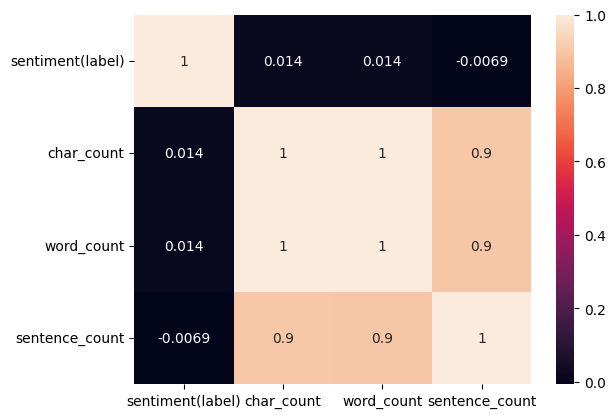

In [36]:
sns.heatmap(df[['sentiment(label)', 'char_count', 'word_count', 'sentence_count']].corr(), annot=True)